**Context:**

The Gurugram-based company ‘FlipItNews’ aims to revolutionize the way Indians perceive finance, business, and capital market investment, by giving it a boost through artificial intelligence (AI) and machine learning (ML). They’re on a mission to reinvent financial literacy for Indians, where financial awareness is driven by smart information discovery and engagement with peers. Through their smart content discovery and contextual engagement, the company is simplifying business, finance, and investment for millennials and first-time investors


**Objective:**

The goal of this project is to use a bunch of news articles extracted from the companies’ internal database and categorize them into several categories like politics, technology, sports, business and entertainment based on their content. Use natural language processing and create & compare at least three different models.

Downloading dataset

In [ ]:
!gdown '1I3-pQFzbSufhpMrUKAROBLGULXcWiB9u'

Downloading...
From: https://drive.google.com/uc?id=1I3-pQFzbSufhpMrUKAROBLGULXcWiB9u
To: /content/flipitnews-data.csv
100% 5.06M/5.06M [00:00<00:00, 18.7MB/s]


Importing necessary libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk

from nltk.tokenize import word_tokenize
nltk.download('punkt')

from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('wordnet')

from nltk import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB


from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix,roc_auc_score

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
df= pd.read_csv('flipitnews-data.csv')
df

,Category,Article
0,Technology,tv future in the hands of viewers with home th...
1,Business,worldcom boss left books alone former worldc...
2,Sports,tigers wary of farrell gamble leicester say ...
3,Sports,yeading face newcastle in fa cup premiership s...
4,Entertainment,ocean s twelve raids box office ocean s twelve...
...,...,...
2220,Business,cars pull down us retail figures us retail sal...
2221,Politics,kilroy unveils immigration policy ex-chatshow ...
2222,Entertainment,rem announce new glasgow concert us band rem h...
2223,Politics,how political squabbles snowball it s become c...


In [ ]:
pprint(df.iloc[0].to_dict(), compact=True)

Pretty printing has been turned ON


Understanding the shape and statistical summary of the dataset

In [ ]:
df.shape

(2225, 2)

In [ ]:
df.describe(include='all')

,Category,Article
count,2225,2225
unique,5,2126
top,Sports,blind student hears in colour a blind studen...
freq,511,2


In [ ]:
df.isna().sum()

,0
Category,0
Article,0


In [ ]:
df.duplicated().sum()

np.int64(99)

In [ ]:
# prompt: How to check the duplicates

# Check for duplicates considering all columns
duplicate_rows = df[df.duplicated()]

# Print or further analyze the duplicated rows
print("Duplicate Rows:")
duplicate_rows

# To remove duplicates, you can use:
# df.drop_duplicates(inplace=True)


Duplicate Rows:


,Category,Article
85,Politics,hague given up his pm ambition former conser...
301,Politics,fox attacks blair s tory lies tony blair lie...
496,Technology,microsoft gets the blogging bug software giant...
543,Business,economy strong in election year uk businesse...
582,Entertainment,ray dvd beats box office takings oscar-nominat...
...,...,...
2206,Politics,kennedy questions trust of blair lib dem leade...
2207,Technology,california sets fines for spyware the makers o...
2213,Technology,progress on new internet domains by early 2005...
2215,Technology,junk e-mails on relentless rise spam traffic i...


**Question 1:**
How many news articles are present in the dataset that we have?

In [ ]:
df.drop_duplicates(inplace=True)
df.shape

(2126, 2)

There are 2126 news Articles in the dataset.

**Questions 2 and 3:**
Most of the news articles are from _____ category.

Only ___ no. of articles belong to the ‘Technology’ category.

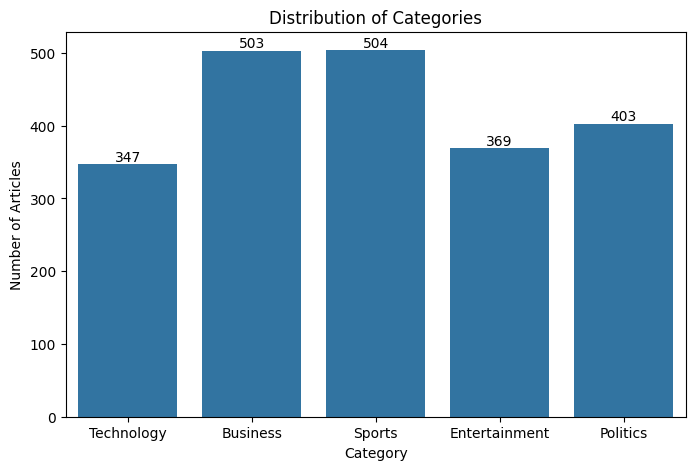

In [ ]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Category', data=df)

ax.bar_label(ax.containers[0])

ax.set_title('Distribution of Categories')
ax.set_xlabel('Category')
ax.set_ylabel('Number of Articles')

plt.show()

Most of the news articles are from Business and Sports Categories.

Only 347 no. of articles belong to the ‘Technology’ category.

In [ ]:
df['Article'][1]

'worldcom boss  left books alone  former worldcom boss bernie ebbers  who is accused of overseeing an $11bn (£5.8bn) fraud  never made accounting decisions  a witness has told jurors.  david myers made the comments under questioning by defence lawyers who have been arguing that mr ebbers was not responsible for worldcom s problems. the phone company collapsed in 2002 and prosecutors claim that losses were hidden to protect the firm s shares. mr myers has already pleaded guilty to fraud and is assisting prosecutors.  on monday  defence lawyer reid weingarten tried to distance his client from the allegations. during cross examination  he asked mr myers if he ever knew mr ebbers  make an accounting decision  .  not that i am aware of   mr myers replied.  did you ever know mr ebbers to make an accounting entry into worldcom books   mr weingarten pressed.  no   replied the witness. mr myers has admitted that he ordered false accounting entries at the request of former worldcom chief financi

In [ ]:
!pip install contractions

In [ ]:
import contractions

In [ ]:
import nltk
nltk.download('punkt_tab')

from nltk.corpus import stopwords
stop_words = list(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

import re
import contractions
from nltk.tokenize import word_tokenize

def nlp_preprocess(text):
  text=re.sub('[^a-zA-Z]',' ',text) #remove text other than letters
  text=text.lower()#convert text to lower case
  expand_text=contractions.fix(text) #expand contractions
  tokens=word_tokenize(expand_text)#split the sentences or text to tokens
  tokens=[token for token in tokens if token not in stop_words] # Remove stop words
  tokens=[lemmatizer.lemmatize(token) for token in tokens] #lemmatization
  new_txt = " ".join(tokens)
  return new_txt

df['Article']=df['Article'].apply(nlp_preprocess)
df['Article'][1]





[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


'worldcom bos left book alone former worldcom bos bernie ebbers accused overseeing bn bn fraud never made accounting decision witness told juror david myers made comment questioning defence lawyer arguing mr ebbers responsible worldcom problem phone company collapsed prosecutor claim loss hidden protect firm share mr myers already pleaded guilty fraud assisting prosecutor monday defence lawyer reid weingarten tried distance client allegation cross examination asked mr myers ever knew mr ebbers make accounting decision aware mr myers replied ever know mr ebbers make accounting entry worldcom book mr weingarten pressed replied witness mr myers admitted ordered false accounting entry request former worldcom chief financial officer scott sullivan defence lawyer trying paint mr sullivan admitted fraud testify later trial mastermind behind worldcom accounting house card mr ebbers team meanwhile looking portray affable bos admission pe graduate economist whatever ability mr ebbers transformed

**Questions 4:**
What are Stop Words and why should they be removed from the text data?

Stop words are the common, frequently used words in a language that usually do not carry significant meaning in the context of natural language processing (NLP) tasks.

Removing stop words helps with:

1. Reducing Noise
They don't add value to analysis and may dilute the signal from more meaningful words.

2. Improving Accuracy
Text models like classification or clustering often perform better without stop words, since they focus on meaningful terms.

3. Reducing Dimensionality
When using techniques like Bag of Words or TF-IDF, stop words add unnecessary dimensions. Removing them reduces computational cost and memory usage.

**Question 5:**
Explain the difference between Stemming and Lemmatization.

Stemming is the process of chopping off prefixes or suffixes of a word to reduce it to its root (stem) form — even if that root isn't a real word.

Example:
"playing", "played", "plays" → "play"
"studies", "studying", "studied" → "studi"

Stemming is rule-based and often leads to crude or inaccurate roots.

Lemmatization is the process of reducing a word to its dictionary base form (lemma) using linguistic knowledge (like part-of-speech, meaning, etc.).

"running" → "run"
"better" → "good"
"was" → "be"

 Lemmatization is more accurate and returns real words, but it’s slower than stemming.

**Encode the target variable (category) using Label/Ordinal encoder.**

In [ ]:
# For encoding the categorical variable
!pip install category_encoders
import category_encoders as ce

In [ ]:
target_encode=ce.OrdinalEncoder(cols='Category')
df=target_encode.fit_transform(df)
df

,Category,Article
0,1,tv future hand viewer home theatre system plas...
1,2,worldcom bos left book alone former worldcom b...
2,3,tiger wary farrell gamble leicester say rushed...
3,3,yeading face newcastle fa cup premiership side...
4,4,ocean twelve raid box office ocean twelve crim...
...,...,...
2220,2,car pull u retail figure u retail sale fell ja...
2221,5,kilroy unveils immigration policy ex chatshow ...
2222,4,rem announce new glasgow concert u band rem an...
2223,5,political squabble snowball become commonplace...


**Outcome labels after encoding -**

Category:

1 - Technology

2 - Business

3 - Sports

4 - Entertainment

5 - Politics

**Create an option for the user to choose between Bag of Words and TF-IDF techniques for vectorizing the data.**

In [ ]:
# For BoW & TF-IDF
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer


In [ ]:
choice = int(input("Choose \n (1) If you want to use Bag of Words \n (2) If you want to use TF-IDF \n Choice: "))

if choice ==1:
  cv=CountVectorizer(max_features=5000)
  X=cv.fit_transform(df['Article']).toarray()
elif choice ==2:
  tf=TfidfVectorizer()
  X=tf.fit_transform(df['Article']).toarray()
else:
  print('Wrong Input')
y=np.array(df['Category'].values)

Choose 
 (1) If you want to use Bag of Words 
 (2) If you want to use TF-IDF 
 Choice: 2


**Question 5:**

Which of the techniques Bag of Words or TF-IDF is considered to be more efficient than the other?

📦 1. Bag of Words (BoW)
🔹 What it does:
Counts how many times each word appears in a document.

Simple frequency-based representation.

✅ Pros:
Simple and fast to compute.

Works well for basic models like Naive Bayes.

❌ Cons:
Doesn’t account for importance of a word in the entire dataset.

Treats all frequent words the same, even if they’re common across all documents.

📊 2. TF-IDF (Term Frequency – Inverse Document Frequency)
🔹 What it does:
Weighs words based on how frequently they appear in one document vs how rare they are across the whole corpus.

Penalizes common words and highlights unique ones.

✅ Pros:
More informative representation than BoW.

Improves performance in many NLP tasks (e.g., text classification, similarity search).

❌ Cons:
Slightly slower to compute.

Still ignores word order and context.

TF-IDF is generally considered more efficient in terms of performance/accuracy trade-off, especially for text classification — although BoW is faster and may work fine for smaller or simpler problems.

**Perform train-test split and train a Naive Bayes classifier model using the simple/classical approach.**

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,shuffle=True,stratify=y,random_state=42)

**Question 6:**
What’s the shape of train & test data sets after performing a 75:25 split.

In [ ]:
print("No. of rows in train set is {}.".format(X_train.shape[0]))
print("No. of rows in test set is {}.".format(X_test.shape[0]))

No. of rows in train set is 1594.
No. of rows in test set is 532.


** Model Training & Evaluation **

 1.Simple Approach

**Naive Bayes Classifier:**

In [ ]:
# Training the Naive Base Model
nb=MultinomialNB()
nb.fit(X_train,y_train)

MultinomialNB()

In [ ]:
# Calculating accuracy score in train and test
y_pred_train=nb.predict(X_train)
y_pred_test=nb.predict(X_test)


print("Train accuracy:{:0.3f}".format(accuracy_score(y_train,y_pred_train)))
print("Train accuracy:{:0.3f}".format(accuracy_score(y_test,y_pred_test)))

Train accuracy:0.988
Train accuracy:0.970


In [ ]:
y_test_pred_proba_nb=nb.predict_proba(X_test)

score =roc_auc_score(y_test,y_test_pred_proba_nb,multi_class='ovr')

print("ROC_AUC_SCORE={:0.3f}".format(score))

ROC_AUC_SCORE=0.998


In [ ]:
# Computing the precision, recall & f1 score -

precision=precision_score(y_test,y_pred_test,average='weighted')
recall=recall_score(y_test,y_pred_test,average='weighted')
f1=f1_score(y_test,y_pred_test,average='weighted')

print("Precision={:0.3f}".format(precision))
print("Recall={:0.3f}".format(recall))
print("F1_Score={:0.3f}".format(f1))

Precision=0.971
Recall=0.970
F1_Score=0.970


Text(50.722222222222214, 0.5, 'Truth')

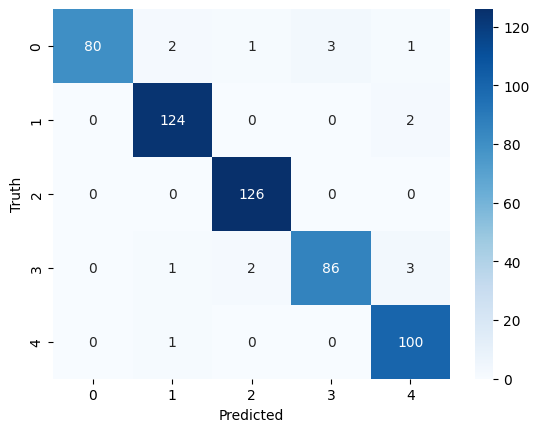

In [ ]:
# Plot confusion matrix

cm= confusion_matrix(y_test,y_pred_test)

sns.heatmap(cm, annot=True, fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [ ]:
#Print Classification Report

print("Confusion Report",classification_report(y_test,y_pred_test))

Confusion Report               precision    recall  f1-score   support

           1       1.00      0.92      0.96        87
           2       0.97      0.98      0.98       126
           3       0.98      1.00      0.99       126
           4       0.97      0.93      0.95        92
           5       0.94      0.99      0.97       101

    accuracy                           0.97       532
   macro avg       0.97      0.97      0.97       532
weighted avg       0.97      0.97      0.97       532



**Functionalize Code:**

In [ ]:
def model_train(obj):
  obj.fit(X_train,y_train)
  y_pred_train=obj.predict(X_train)
  y_pred_test=obj.predict(X_test)
  y_pred_test_proba=obj.predict_proba(X_test)
  return y_pred_train,y_pred_test,y_pred_test_proba


In [ ]:
def model_evaluation(y_pred_train,y_pred_test,y_pred_test_proba):
  print("------------------------------------")

  #Calculating train and test accuracy
  print("Train accuracy:{:0.3f}".format(accuracy_score(y_train,y_pred_train)))
  print("Test accuracy:{:0.3f}".format(accuracy_score(y_test,y_pred_test)))

  #Calculate ROC_AUC_SCORE
  score =roc_auc_score(y_test,y_pred_test_proba,multi_class='ovr')
  print("ROC_AUC_SCORE={:0.3f}".format(score))

  #Caculate precision,recall and f1_score
  precision=precision_score(y_test,y_pred_test,average='weighted')
  recall=recall_score(y_test,y_pred_test,average='weighted')
  f1=f1_score(y_test,y_pred_test,average='weighted')
  print("Precision={:0.3f}".format(precision))
  print("Recall={:0.3f}".format(recall))
  print("F1_Score={:0.3f}".format(f1))
  print("------------------------------------")


**Naive Bayes Classification using above code:**

In [ ]:
nb=MultinomialNB()
y_pred_train,y_pred_test,y_pred_test_proba=model_train(nb)
model_evaluation(y_pred_train,y_pred_test,y_pred_test_proba)

------------------------------------
Train accuracy:0.988
Test accuracy:0.970
ROC_AUC_SCORE=0.998
Precision=0.971
Recall=0.970
F1_Score=0.970
------------------------------------


**Decision Tree Classifier:**

In [ ]:
dt=DecisionTreeClassifier()
y_pred_train,y_pred_test,y_pred_test_proba=model_train(dt)
model_evaluation(y_pred_train,y_pred_test,y_pred_test_proba)

------------------------------------
Train accuracy:1.000
Test accuracy:0.842
ROC_AUC_SCORE=0.897
Precision=0.846
Recall=0.842
F1_Score=0.841
------------------------------------


**Nearest Neighbours:**

In [ ]:
knn=KNeighborsClassifier(n_neighbors=5)
y_pred_train,y_pred_test,y_pred_test_proba=model_train(knn)
model_evaluation(y_pred_train,y_pred_test,y_pred_test_proba)

------------------------------------
Train accuracy:0.968
Test accuracy:0.930
ROC_AUC_SCORE=0.986
Precision=0.932
Recall=0.930
F1_Score=0.930
------------------------------------


**Random Forest Classifier:**

In [ ]:
rf=RandomForestClassifier()
y_pred_train,y_pred_test,y_pred_test_proba=model_train(rf)
model_evaluation(y_pred_train,y_pred_test,y_pred_test_proba)


------------------------------------
Train accuracy:1.000
Test accuracy:0.953
ROC_AUC_SCORE=0.998
Precision=0.954
Recall=0.953
F1_Score=0.953
------------------------------------


**Question 7:**

Which of the above models is found to be the best performing model..


**Out of all the models , Naive Bayes Classifier outperforms with highest test accuracy. **

**Question 8:**According to this particular use case, both precision and recall are equally important. (T/F)

Yes — Precision and Recall are Equally Important because:
Misclassifying business as sports or technology as entertainment can confuse users or mislead recommendations.

High recall ensures all relevant articles are detected.

High precision ensures irrelevant articles aren’t mislabeled.

Hence,  should focus on both precision and recall, and use the F1-score (harmonic mean) to evaluate your model.